### Upload from Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())
!nvidia-smi

GPU Available: True
Mon Mar  2 12:09:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [ ]:
!cp -r "/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/train" /content/
!cp -r "/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/val" /content/

In [ ]:
train_dir = "/content/PlantVillage/train"
val_dir   = "/content/PlantVillage/val"

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="/content/train",
    transform=train_transforms
)

val_dataset = ImageFolder(
    root="/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/val",
    transform=val_transforms
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)    # expected: [32, 3, 224, 224]
print(labels[:5])      # sample labels

torch.Size([32, 3, 224, 224])
tensor([24,  4, 30, 24, 35])


In [ ]:
from collections import Counter
import torch
import torch.nn as nn

targets = train_dataset.targets
class_counts = Counter(targets)

total_samples = len(targets)
num_classes = len(class_counts)

class_weights = [
    total_samples / class_counts[i]
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

In [ ]:
targets = train_dataset.targets
class_counts = Counter(targets)

In [ ]:
total_samples = len(targets)
num_classes = len(class_counts)

class_weights = [
    total_samples / class_counts[i]
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def unnormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

In [ ]:
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

class_names = train_dataset.classes

In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, num_classes):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 224 * 224, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

mlp_model = MLP(num_classes).to(device)

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1),  # 224x224 -> 224x224
            nn.ReLU(),
            nn.MaxPool2d(2,2),          # 224 -> 112
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),          # 112 -> 56
            nn.Conv2d(64, 128, 3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)           # 56 -> 28
        )

        # Dynamically compute flatten size
        dummy_input = torch.zeros(1,3,224,224)
        with torch.no_grad():
            n_features = self.features(dummy_input).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate model
cnn_model = SimpleCNN(num_classes).to(device)
print(cnn_model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=38, bias=True)
  )
)


In [ ]:
def train_model(model, train_loader, val_loader, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_acc = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    return val_acc

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
print("Training MLP...")
mlp_val_acc = train_model(mlp_model, train_loader, val_loader, epochs=5)

Training MLP...
Epoch [1/5] Train Acc: 10.94% | Val Acc: 15.17%
Epoch [2/5] Train Acc: 16.70% | Val Acc: 18.98%
Epoch [3/5] Train Acc: 16.43% | Val Acc: 15.04%
Epoch [4/5] Train Acc: 15.41% | Val Acc: 15.28%
Epoch [5/5] Train Acc: 13.55% | Val Acc: 14.43%


In [ ]:
print("Training CNN...")
cnn_val_acc = train_model(cnn_model, train_loader, val_loader, epochs=5)

Training CNN...
Epoch [1/5] Train Acc: 44.87% | Val Acc: 74.81%
Epoch [2/5] Train Acc: 68.68% | Val Acc: 80.76%
Epoch [3/5] Train Acc: 74.10% | Val Acc: 82.11%
Epoch [4/5] Train Acc: 78.92% | Val Acc: 88.75%
Epoch [5/5] Train Acc: 80.90% | Val Acc: 88.20%


In [ ]:
print("\nFinal Comparison:")
print(f"MLP Validation Accuracy: {mlp_val_acc:.2f}%")
print(f"CNN Validation Accuracy: {cnn_val_acc:.2f}%")


Final Comparison:
MLP Validation Accuracy: 14.43%
CNN Validation Accuracy: 88.20%


In [ ]:
mlp_train_acc = [10.94, 16.70, 16.43, 15.41, 13.55]
mlp_val_acc   = [15.17, 18.98, 15.04, 15.28, 14.43]

In [ ]:
cnn_train_acc = [44.87, 68.68, 74.10, 78.92, 80.90]
cnn_val_acc   = [74.81, 80.76, 82.11, 88.75, 88.20]

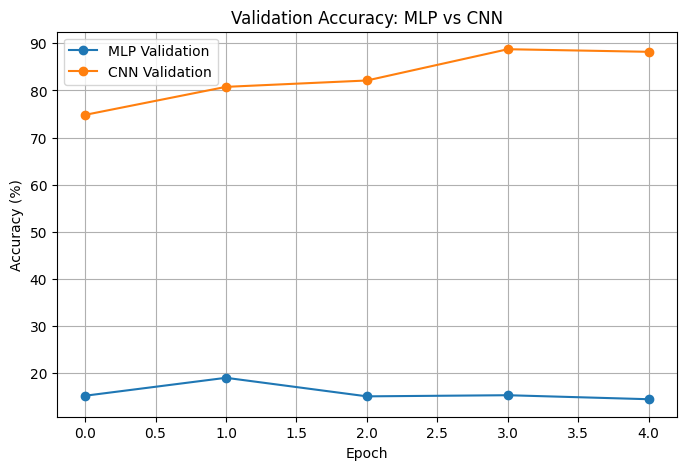

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mlp_val_acc, marker='o', label="MLP Validation")
plt.plot(cnn_val_acc, marker='o', label="CNN Validation")

plt.title("Validation Accuracy: MLP vs CNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

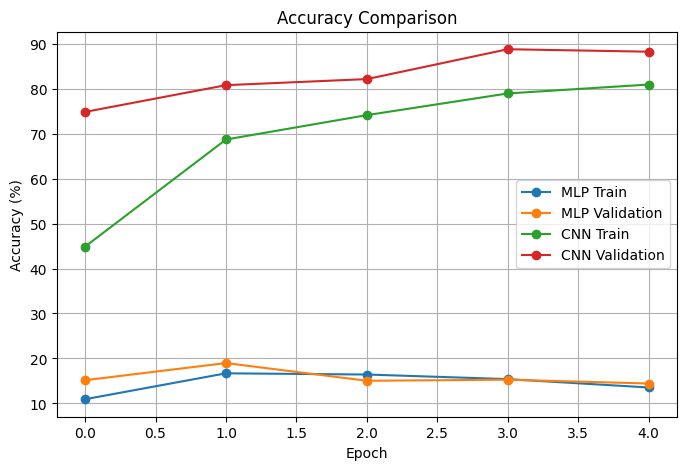

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(mlp_train_acc, marker='o', label="MLP Train")
plt.plot(mlp_val_acc, marker='o', label="MLP Validation")
plt.plot(cnn_train_acc, marker='o', label="CNN Train")
plt.plot(cnn_val_acc, marker='o', label="CNN Validation")

plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def get_val_loss(model, loader):
    model.eval()
    loss_total = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item() * labels.size(0)
            total += labels.size(0)

    return loss_total / total

In [ ]:
mlp_loss = get_val_loss(mlp_model, val_loader)
cnn_loss = get_val_loss(cnn_model, val_loader)

print("MLP Validation Loss:", mlp_loss)
print("CNN Validation Loss:", cnn_loss)

MLP Validation Loss: 3.302643712054694
CNN Validation Loss: 0.3546171605103471


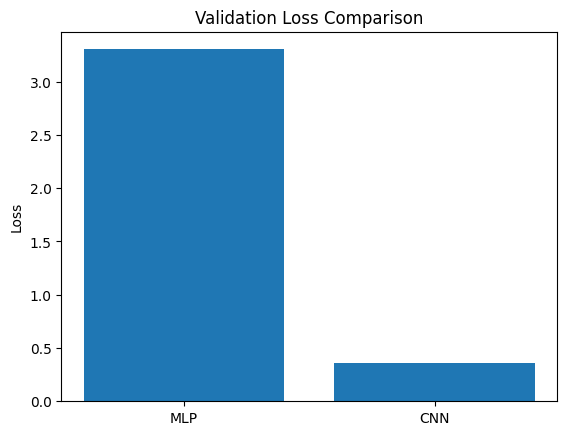

In [ ]:
plt.bar(["MLP", "CNN"], [mlp_loss, cnn_loss])
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.show()

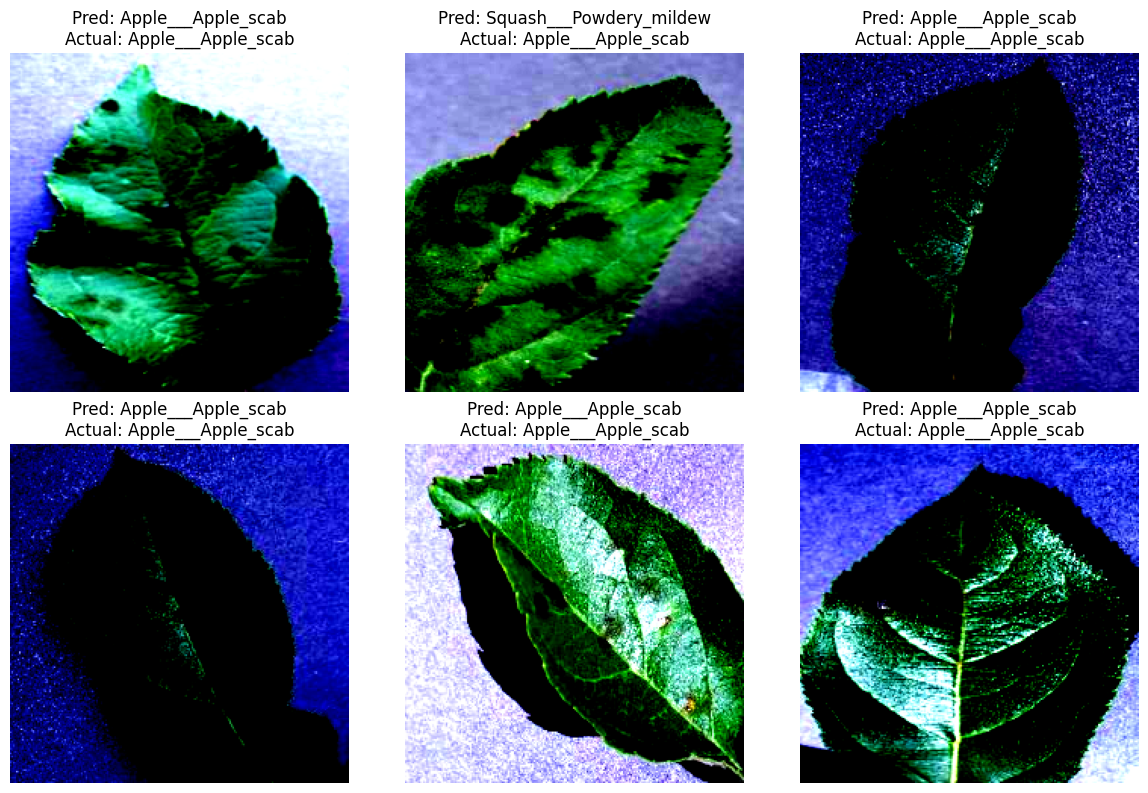

In [ ]:
classes = train_loader.dataset.classes

cnn_model.eval()

images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

outputs = cnn_model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(f"Pred: {classes[preds[i]]}\nActual: {classes[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

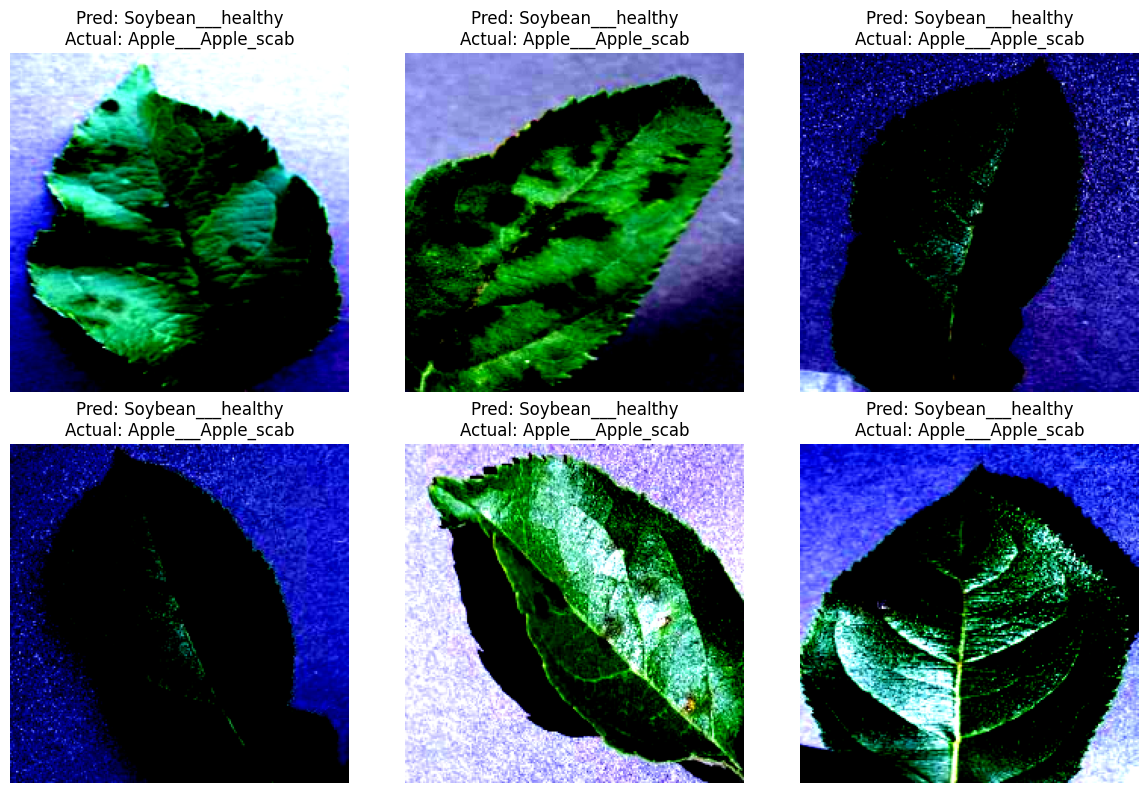

In [ ]:
mlp_model.eval()

images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

# flatten images for MLP
images_flat = images.view(images.size(0), -1)

outputs = mlp_model(images_flat)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(f"Pred: {classes[preds[i]]}\nActual: {classes[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
torch.save(cnn_model.state_dict(), "best_model.pth")

In [ ]:
torch.save(cnn_model.state_dict(),
           "/content/drive/MyDrive/best_model.pth")

In [ ]:
!ls

best_model.pth	drive  sample_data  train  val
